Baseline model for batch monitoring example

In [2]:
import datetime
import pandas as pd

from joblib import load, dump
from tqdm import tqdm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [3]:
df = pd.read_parquet("../data/green_tripdata_2024-03.parquet")
df.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,57457.000000,57457,57457,55360.000000,57457.000000,57457.000000,55360.000000,57457.000000,57457.000000,57457.000000,57457.000000,57457.000000,57457.000000,0.0,57457.000000,57457.000000,55360.000000,55353.000000,55360.000000
mean,1.877334,2024-03-16 04:02:52.405399,2024-03-16 04:21:00.076039,1.179986,95.524688,138.629149,1.309538,13.522828,17.313474,0.904472,0.577410,2.386255,0.192537,NaN,0.979378,22.904832,1.321062,1.038047,0.737730
min,1.000000,2008-12-31 23:02:24,2008-12-31 23:02:30,1.000000,1.000000,1.000000,0.000000,0.000000,-295.080000,-2.500000,-0.500000,-1.560000,0.000000,NaN,-1.000000,-296.080000,1.000000,1.000000,-2.750000
25%,2.000000,2024-03-08 13:53:56,2024-03-08 14:13:49,1.000000,74.000000,74.000000,1.000000,1.100000,9.300000,0.000000,0.500000,0.000000,0.000000,NaN,1.000000,13.440000,1.000000,1.000000,0.000000
50%,2.000000,2024-03-15 22:49:01,2024-03-15 23:09:52,1.000000,75.000000,138.000000,1.000000,1.790000,13.500000,0.000000,0.500000,2.000000,0.000000,NaN,1.000000,18.500000,1.000000,1.000000,0.000000
75%,2.000000,2024-03-23 20:11:25,2024-03-23 20:34:48,1.000000,97.000000,220.000000,1.000000,3.100000,19.800000,1.000000,0.500000,3.610000,0.000000,NaN,1.000000,27.050000,2.000000,1.000000,2.750000
max,2.000000,2024-04-01 00:01:45,2024-04-01 16:11:00,99.000000,265.000000,265.000000,9.000000,125112.200000,841.600000,10.000000,4.250000,150.000000,26.760000,NaN,1.000000,856.980000,5.000000,2.000000,2.750000
std,0.328056,NaN,NaN,1.356719,57.285088,76.295346,0.967749,770.416255,14.958249,1.382446,0.366916,3.159273,1.184551,NaN,0.154253,17.013735,0.497858,0.191311,1.218039


In [4]:
df.shape

(57457, 20)

In [6]:
# create target
df["duration_min"] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration_min = df.duration_min.apply(lambda td : float(td.total_seconds())/60)

In [7]:
# filter out outliers
df = df[(df.duration_min >= 0) & (df.duration_min <= 60)]
df = df[(df.passenger_count > 0) & (df.passenger_count <= 8)]

<Axes: >

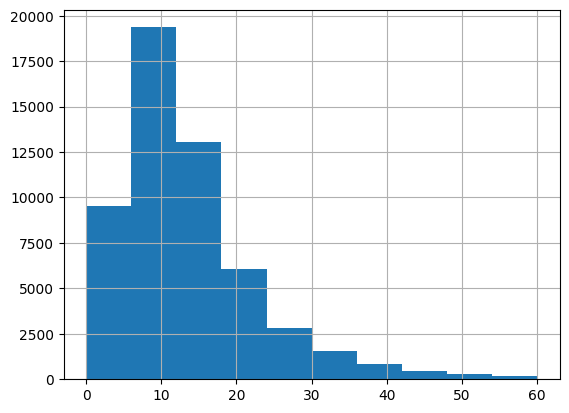

In [8]:
df.duration_min.hist()

In [9]:
# data labeling
target = "duration_min"
num_features = ["passenger_count", "trip_distance", "fare_amount", "total_amount"]
cat_features = ["PULocationID", "DOLocationID"]

In [10]:
df.shape

(54135, 21)

In [11]:
train_data = df[:30000]
test_data = df[30000:]

In [12]:
model = LinearRegression()

In [13]:
model.fit(train_data[num_features + cat_features], train_data[target])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
train_preds = model.predict(train_data[num_features + cat_features])
train_data['prediction'] = train_preds

C:\Users\anshu\AppData\Local\Temp\ipykernel_22400\3810346118.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['prediction'] = train_preds


In [15]:
val_preds = model.predict(test_data[num_features + cat_features])
test_data['prediction'] = val_preds


C:\Users\anshu\AppData\Local\Temp\ipykernel_22400\611060988.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['prediction'] = val_preds


In [16]:
print(mean_absolute_error(train_data.duration_min, train_data.prediction))
print(mean_absolute_error(test_data.duration_min, test_data.prediction))

3.7724732393594484
3.716814567929369


In [17]:
with open('models/lin_reg.bin', 'wb') as f_out:
    dump(model, f_out)

In [18]:
test_data.to_parquet('data/reference.parquet')

### Evidently Report

In [24]:
from evidently import Report, Dataset, DataDefinition
from evidently.presets import DataDriftPreset

In [27]:
eval_data = Dataset.from_pandas(
    df,
    data_definition=DataDefinition()
)


C:\Users\anshu\AppData\Roaming\Python\Python312\site-packages\evidently\core\datasets.py:995: RuntimeWarning: invalid value encountered in scalar divide
  infinite=StatCountValue(infinite_count, infinite_count / data.count()),


In [28]:
report = Report([DataDriftPreset()])
report_result = report.run(current_data=train_data, reference_data=test_data)

C:\Users\anshu\AppData\Roaming\Python\Python312\site-packages\evidently\core\datasets.py:995: RuntimeWarning: invalid value encountered in scalar divide
  infinite=StatCountValue(infinite_count, infinite_count / data.count()),
C:\Users\anshu\AppData\Roaming\Python\Python312\site-packages\evidently\core\datasets.py:995: RuntimeWarning: invalid value encountered in scalar divide
  infinite=StatCountValue(infinite_count, infinite_count / data.count()),


ValueError: An empty column 'ehail_fee' was provided for drift calculation in the reference dataset.

In [ ]:
report.show(mode='inline')

In [ ]:
result = report.as_dict()

In [ ]:
result